# Laboratorio 4 — Inciso 1: Conexión con el API de Sentinel Hub

Se establece la conexión con la Process API y la Catalog API de Sentinel Hub sobre la infraestructura del Copernicus Data Space Ecosystem (CDSE), mediante el módulo `sentinelhub-py`. Las credenciales se leen del perfil `cdse` del archivo de configuración global de la librería, ubicado fuera de este repositorio, con una alternativa de variables de entorno como respaldo.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd

from src.conexion import consultar_catalogo_todos, crear_config, verificar_conexion
from src.config import FECHA_COBERTURA_PARCIAL, RUTA_DATA_PROCESSED, RUTA_FIGURAS

## Autenticación OAuth

In [2]:
config = crear_config()
estado_conexion = verificar_conexion(config)
estado_conexion

{'autenticado': True,
 'endpoint': 'https://sh.dataspace.copernicus.eu',
 'expira_utc': '2026-08-16T22:08:17+00:00'}

## Consulta al catálogo de escenas

Se consulta la Catalog API para las 22 fechas oficiales (11 por lago) y se compara la nubosidad reportada por el catálogo, calculada sobre la escena completa, contra la nubosidad oficial provista en el enunciado.

In [3]:
catalogo = consultar_catalogo_todos(config)
catalogo

,lago,fecha,id_producto,plataforma,nubosidad_catalogo_pct,nubosidad_oficial_pct,satelite_oficial
0,atitlan,2025-01-18,S2B_MSIL1C_20250118T162519_N0511_R040_T15PXS_2...,sentinel-2b,1.23,0.02,Sentinel-2B
1,atitlan,2025-04-13,S2C_MSIL1C_20250413T161851_N0511_R040_T15PXS_2...,sentinel-2c,0.18,0.54,Sentinel-2C
2,atitlan,2025-05-13,S2C_MSIL1C_20250513T161851_N0511_R040_T15PXS_2...,sentinel-2c,3.49,4.37,Sentinel-2C
3,atitlan,2025-07-17,S2A_MSIL1C_20250717T163711_N0511_R083_T15PXS_2...,sentinel-2a,1.51,3.57,Sentinel-2A
4,atitlan,2025-11-21,S2A_MSIL1C_20251121T162701_N0511_R040_T15PXS_2...,sentinel-2a,1.93,3.15,Sentinel-2A
5,atitlan,2025-12-29,S2C_MSIL1C_20251229T162941_N0511_R040_T15PXS_2...,sentinel-2c,11.82,3.17,Sentinel-2C
6,atitlan,2026-02-12,S2B_MSIL1C_20260212T162309_N0512_R040_T15PXS_2...,sentinel-2b,0.00,0.04,Sentinel-2B
7,atitlan,2026-03-24,S2B_MSIL1C_20260324T161859_N0512_R040_T15PXS_2...,sentinel-2b,2.60,3.17,Sentinel-2B
8,atitlan,2026-04-13,S2B_MSIL1C_20260413T161829_N0512_R040_T15PXS_2...,sentinel-2b,0.01,0.01,Sentinel-2B
9,atitlan,2026-04-28,S2C_MSIL1C_20260428T161901_N0512_R040_T15PXS_2...,sentinel-2c,7.91,4.96,Sentinel-2C


In [4]:
catalogo.to_csv(RUTA_DATA_PROCESSED / "catalogo_escenas.csv", index=False)
catalogo["id_producto"].isna().sum()

np.int64(0)

## Comparación de nubosidad oficial vs. catálogo

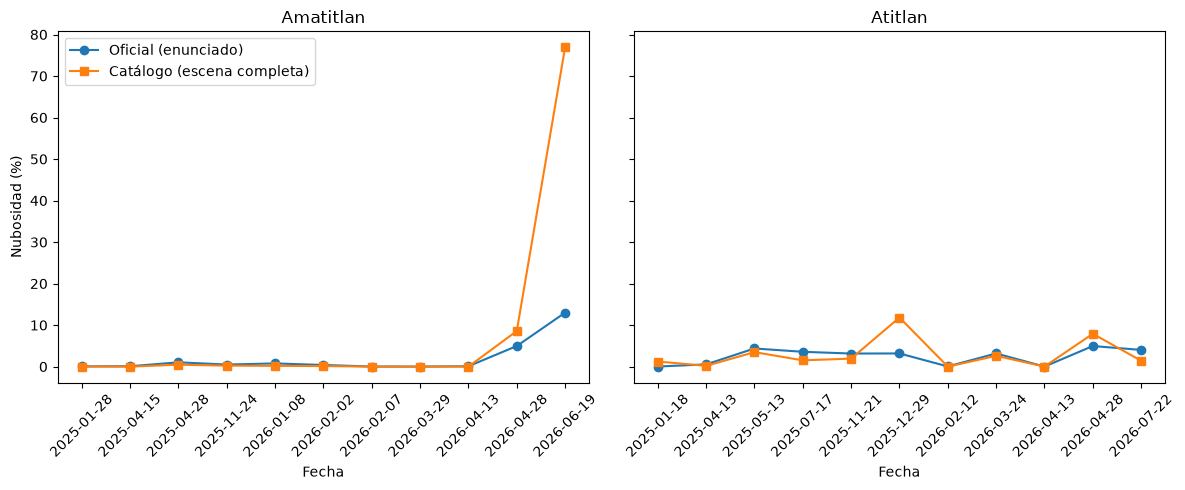

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, lago in zip(axes, sorted(catalogo["lago"].unique())):
    sub = catalogo[catalogo["lago"] == lago]
    ax.plot(sub["fecha"], sub["nubosidad_oficial_pct"], marker="o", label="Oficial (enunciado)")
    ax.plot(sub["fecha"], sub["nubosidad_catalogo_pct"], marker="s", label="Catálogo (escena completa)")
    ax.set_title(lago.capitalize())
    ax.set_xlabel("Fecha")
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Nubosidad (%)")
axes[0].legend()
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "nubosidad_comparacion.png", dpi=150)
plt.show()

La nubosidad oficial corresponde a la fracción de nubes dentro del polígono de cada lago, mientras que la nubosidad del catálogo se calcula sobre la escena Sentinel-2 completa (aproximadamente 110x110 km). Por esa diferencia de área ambas series no coinciden en valor absoluto, pero siguen una tendencia consistente: las fechas con mayor nubosidad oficial también presentan valores más altos en el catálogo.

La fecha `2026-02-07` de Amatitlán se mantiene en la lista de fechas oficiales pese a tener una cobertura válida parcial de aproximadamente 57.1%, según se indica en el enunciado. Esta fecha se conserva en el catálogo y se marca para que el análisis temporal del inciso 4 la interprete con cautela.

In [6]:
FECHA_COBERTURA_PARCIAL

{'lago': 'amatitlan', 'fecha': '2026-02-07', 'cobertura_pct': 57.1}